A driver for a simple RBF-PU method

In [131]:
import numpy as np
from rbf.pde.nodes import poisson_disc_nodes
from PuHelper import *
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [132]:
delta = 0.05
vert = np.array([[0, 0], [1, 0], [1, 1], [0, 1]])
edges = np.array([[0, 1], [1, 2], [2, 3], [3, 0]])
nodes, groups, _ = poisson_disc_nodes(delta, (vert, edges))

Generated 2 nodes.


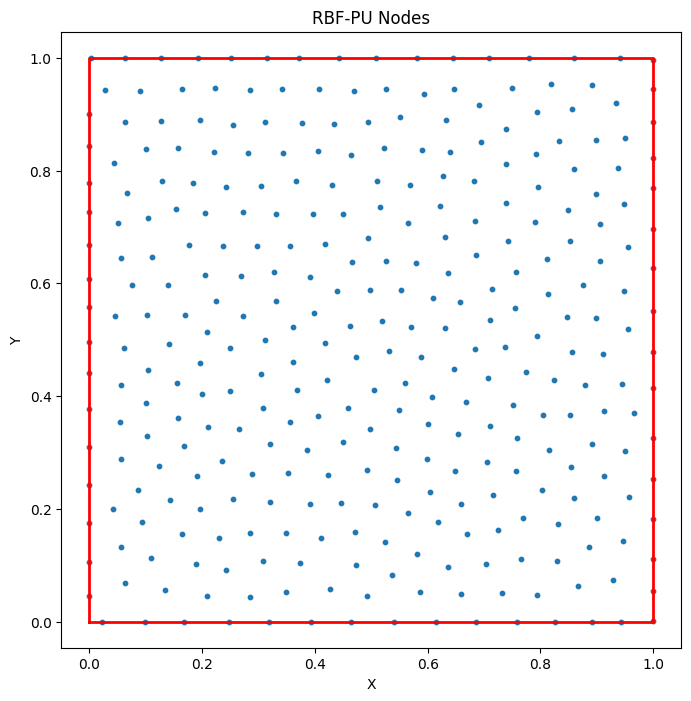

In [133]:
print(f"Generated {len(nodes[0])} nodes.")
nodes_coords = nodes
plt.figure(figsize=(8, 8))
plt.scatter(nodes_coords[:, 0], nodes_coords[:, 1], s=10)
plt.plot(vert[[0, 1, 2, 3, 0], 0], vert[[0, 1, 2, 3, 0], 1], 'r-', linewidth=2)
plt.axis('equal')
plt.title('RBF-PU Nodes')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [134]:
nodes_in_patch= 10
overlap = 3
centers = GenCenters(nodes, nodes_in_patch, overlap)
print(f"Generated {len(centers)} centers.")
print(f"We have {len(nodes)} nodes and {len(centers)} centers, with {nodes_in_patch} nodes per patch and an overlap of {overlap}.")

Generated 97 centers.
We have 326 nodes and 97 centers, with 10 nodes per patch and an overlap of 3.


Generated 2 nodes.


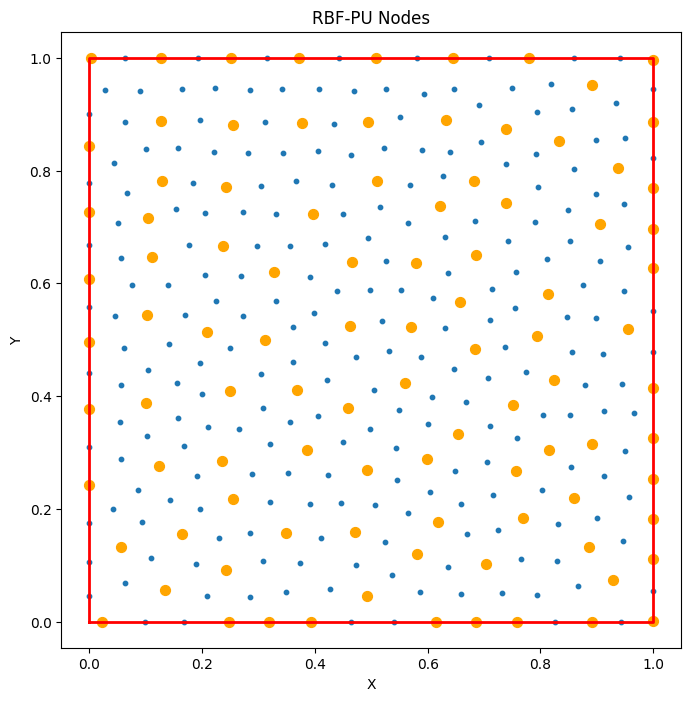

In [135]:
print(f"Generated {len(nodes[0])} nodes.")
nodes_coords = nodes
plt.figure(figsize=(8, 8))
plt.scatter(nodes_coords[:, 0], nodes_coords[:, 1], s=10)
plt.scatter(np.array(centers)[:, 0], np.array(centers)[:, 1], s=50, c='orange', label='Centers')
plt.plot(vert[[0, 1, 2, 3, 0], 0], vert[[0, 1, 2, 3, 0], 1], 'r-', linewidth=2)
plt.axis('equal')
plt.title('RBF-PU Nodes')
plt.xlabel('X')
plt.ylabel('Y')
plt.show()

In [136]:
patches, radii = GenPatches(nodes, centers, nodes_in_patch)

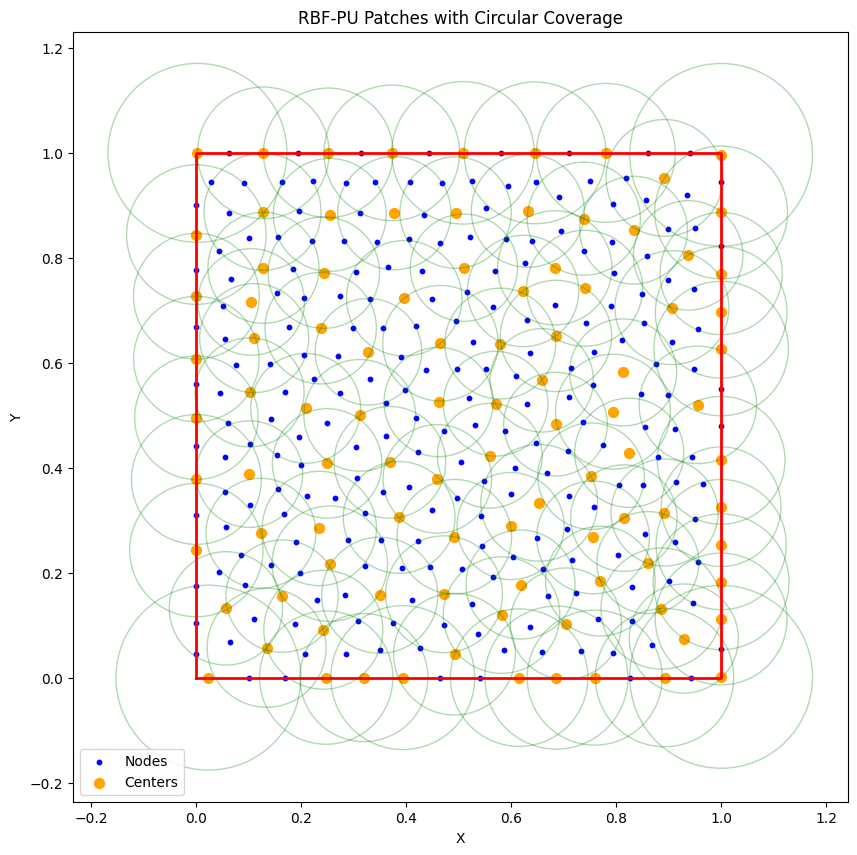

Max patch radius: 0.1761
Min patch radius: 0.0972
Mean patch radius: 0.1149


In [137]:
# Plot the circular patches
plt.figure(figsize=(10, 10))
plt.scatter(nodes_coords[:, 0], nodes_coords[:, 1], s=10, c='blue', label='Nodes')
plt.scatter(np.array(centers)[:, 0], np.array(centers)[:, 1], s=50, c='orange', label='Centers')

# Draw circles for each patch
for center, radius in zip(centers, radii):
    circle = plt.Circle(center, radius, fill=False, edgecolor='green', alpha=0.3)
    plt.gca().add_patch(circle)

plt.plot(vert[[0, 1, 2, 3, 0], 0], vert[[0, 1, 2, 3, 0], 1], 'r-', linewidth=2)
plt.axis('equal')
plt.title('RBF-PU Patches with Circular Coverage')
plt.xlabel('X')
plt.ylabel('Y')
plt.legend()
plt.show()

print(f"Max patch radius: {np.max(radii):.4f}")
print(f"Min patch radius: {np.min(radii):.4f}")
print(f"Mean patch radius: {np.mean(radii):.4f}")


## Interpolation

In [138]:
f = nodes[:, 0]**2 + nodes[:, 1]**2

epsilon = 2

In [ ]:
matrices = GenInterpolationMatrices(nodes, centers, patches, epsilon)
weights = GenWeights(patches, matrices, f)


